In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)

from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

from ISLP import confusion_table
from sklearn.model_selection import train_test_split


from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, classification_report

In [2]:
data = load_data("Weekly")
data

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1089 non-null   int64   
 1   Lag1       1089 non-null   float64 
 2   Lag2       1089 non-null   float64 
 3   Lag3       1089 non-null   float64 
 4   Lag4       1089 non-null   float64 
 5   Lag5       1089 non-null   float64 
 6   Volume     1089 non-null   float64 
 7   Today      1089 non-null   float64 
 8   Direction  1089 non-null   category
dtypes: category(1), float64(7), int64(1)
memory usage: 69.4 KB


In [4]:
data.iloc[:, 0:8].corr()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


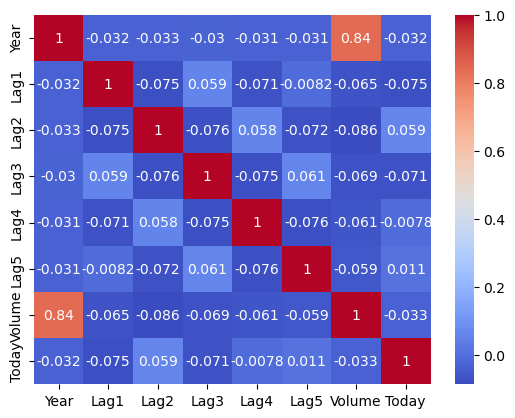

In [5]:
heat_df = data.iloc[:, 0:8].corr()

sns.heatmap(heat_df, annot=True, cmap="coolwarm")
plt.show()

In [6]:
# according to the heatmap we can see correlation between volume and the year.

# b) creating logistic reg
X = data.iloc[:, 0:8]

y = pd.get_dummies(data["Direction"], drop_first=True)

y

,Up
0,False
1,False
2,True
3,True
4,True
...,...
1084,True
1085,True
1086,True
1087,True


C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


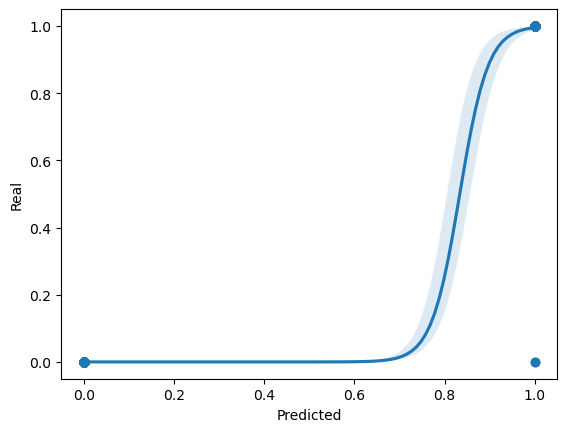

In [7]:
model = LogisticRegression()

model.fit(X, y)
y_pred = model.predict(X)

sns.regplot(x=y_pred, y=y, logistic=True)
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

# Dla niskich wartości przewidywanego prawdopodobieństwa (0–0.7) linia jest niemal pozioma przy 0 → model dobrze rozpoznaje klasę 0.

# Dla wysokich wartości (>0.8) linia rośnie gwałtownie do 1 → model dobrze rozpoznaje klasę 1.

# Generalnie wygląda na dobrze skalibrowany model dla wartości bliskich 0 i 1, co jest typowe przy klasyfikacji binarnej z wyraźną separacją klas. 

# TO jest dla plota ze zlymi parametrami!

In [8]:
# uzywam teraz sm.GLM, bo LogisticRegression() nie daje mi fajnego podsumowania (summary)
X = data.iloc[:, 1:7]
model = sm.GLM(y, X, family=sm.families.Binomial())
results = model.fit()
print(results.summary())

# wynik dla Lag2 i Volume jest statystycznie istotny (Pval)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                     Up   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1083
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -748.03
Date:                Tue, 04 Nov 2025   Deviance:                       1496.1
Time:                        12:13:54   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):          0.0001306
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Lag1          -0.0327      0.026     -1.250      0.2

In [9]:
# c)
probabilities = results.predict()
#len(probabilities)
labels = np.array(["Down"]*1089)
labels[probabilities>0.5] = "Up"

np.unique(labels, return_counts=True)
np.unique(data["Direction"], return_counts=True)

print(confusion_table(labels, data["Direction"]))

acc = (172+427)/(312+427+172+178)
print(acc)

Truth      Down   Up
Predicted           
Down        172  178
Up          312  427
0.5500459136822773


In [10]:
# d)
X_train, X_test, Y_train, Y_test = train_test_split(data["Lag2"], y, test_size=0.1, shuffle=False)
len(Y_train)
model = sm.GLM(Y_train, X_train, family=sm.families.Binomial())
res = model.fit()
res_val = res.predict(X_test)

len(res_val)
labels = np.array([False]*109)
labels[res_val>0.5] = True

print(confusion_table(labels, Y_test))

acc = (25+24)/(25+21+24+39)
print(acc)

# unique, counts = np.unique(Y_train, return_counts=True)
# print(dict(zip(unique.)))

Truth      False  True 
Predicted              
False         21     25
True          24     39
0.44954128440366975


In [11]:
# e) LDA
lda = LDA()

X_mod_train = X_train.to_frame()

Y_train = Y_train.squeeze() 
Y_test = Y_test.squeeze()   
mod = lda.fit(X_mod_train, Y_train)

X_mod_test = X_test.to_frame()
res = mod.predict(X_mod_test)

labels = np.array([False] *109)
labels[res>0.5] = True
print(confusion_table(labels, Y_test))

acc = (9+60)/(9+60+36+4)
acc

Truth      False  True 
Predicted              
False          9      4
True          36     60


0.6330275229357798

In [12]:
# f) QDA
qda = QDA()

X_mod_train = X_train.to_frame()

Y_train = Y_train.squeeze() 
Y_test = Y_test.squeeze()   

mod = qda.fit(X_mod_train, Y_train)

X_mod_test = X_test.to_frame()
res = mod.predict(X_mod_test)

labels = np.array([False] *109)
labels = res
print(confusion_table(labels, Y_test))

acc = (64)/(64+45)
acc
print("\n")
print(classification_report(Y_test, res, zero_division=0))


Truth      False  True 
Predicted              
False          0      0
True          45     64


              precision    recall  f1-score   support

       False       0.00      0.00      0.00        45
        True       0.59      1.00      0.74        64

    accuracy                           0.59       109
   macro avg       0.29      0.50      0.37       109
weighted avg       0.34      0.59      0.43       109



In [13]:
# g) KNN
KNN = KNeighborsClassifier(n_neighbors=1)

X_mod_train = X_train.to_frame()

mod = KNN.fit(X_mod_train, Y_train)

X_mod_test = X_test.to_frame()
res = mod.predict(X_mod_test)

labels = np.array([False] *109)
labels = res
print(confusion_table(labels, Y_test))

acc = (22+33)/(22+33+23+31)
acc


Truth      False  True 
Predicted              
False         22     31
True          23     33


0.5045871559633027

In [14]:
# h) Naive Bayes
from sklearn.naive_bayes import GaussianNB

Naive = GaussianNB()
mod = Naive.fit(X_train.to_frame(), np.array(Y_train).ravel())

res = mod.predict(X_test.to_frame())
labels = res

print(confusion_table(labels, Y_test))

acc = ((64)/(45+64))
print(acc)  

print(accuracy_score(Y_test, labels))


Truth      False  True 
Predicted              
False          0      0
True          45     64
0.5871559633027523
0.5871559633027523


In [15]:
# i) widac ze LDA sprawdza sie najlepiej, QDA i NaiwnyBayes sobie nie radza

In [16]:
# j)
X = data.iloc[:, [0,2,4,6]]
y = pd.get_dummies(data["Direction"], drop_first=True)

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.15, shuffle=False)

model = sm.GLM(Y_train, X_train, family=sm.families.Binomial())
res = model.fit()
res_val = res.predict(X_test)

len(res_val)
labels = np.array([False]*164)
labels = res_val.astype(bool)

Y_test = Y_test
print(confusion_table(labels, Y_test))

print(accuracy_score(Y_test, labels))


Truth      False  True 
Predicted              
False          0      0
True          76     88
0.5365853658536586


In [17]:
KNN = KNeighborsClassifier(n_neighbors=13)
KNN.fit(X_train, np.array(Y_train).ravel())

res = KNN.predict(X_test)

print(confusion_table(res, Y_test))
print(accuracy_score(Y_test, res))


Truth      False  True 
Predicted              
False         28     26
True          48     62
0.5487804878048781
